In [24]:
%matplotlib inline

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, GridSearchCV, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report,
    ConfusionMatrixDisplay,
    f1_score,
    recall_score,
    precision_score,
    accuracy_score,
)

sns.set_theme(style="whitegrid")

train = pd.read_csv("../data/train.csv")
test  = pd.read_csv("../data/test.csv")

X_train = train.drop(columns=["RiskLevel"])
y_train = train["RiskLevel"]
X_test  = test.drop(columns=["RiskLevel"])
y_test  = test["RiskLevel"]

LABELS = ["low risk", "mid risk", "high risk"]
print(X_train.shape, y_train.value_counts().to_dict())

(360, 6) {'low risk': 186, 'high risk': 89, 'mid risk': 85}


## Logistic Regression
## Подбор гиперпараметров
Стратифицированный 5-fold CV, метрика отбора — f1_macro.

In [25]:
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(
        class_weight="balanced",
        max_iter=4000,
        random_state=42,
    )),
])

C_grid = np.logspace(-2, 2, 9)  # 0.01 … 100

param_grid = [{
    "clf__solver": ["saga"],
    "clf__C": [0.01, 0.03, 0.1, 0.3, 1, 3, 10, 30, 100],
    "clf__l1_ratio": [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0],
    "clf__class_weight": ["balanced", None],
}]

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

search = GridSearchCV(
    pipe, param_grid,
    scoring="f1_macro",
    cv=cv, n_jobs=-1, refit=True,
    return_train_score=True,
)

t0 = time.perf_counter()
search.fit(X_train, y_train)
print(f"grid search: {time.perf_counter() - t0:.1f} сек")
print("best:", search.best_params_)
print(f"CV f1_macro: {search.best_score_:.3f} ± {search.cv_results_['std_test_score'][search.best_index_]:.3f}")

grid search: 6.9 сек
best: {'clf__C': 0.03, 'clf__class_weight': 'balanced', 'clf__l1_ratio': 0.5, 'clf__solver': 'saga'}
CV f1_macro: 0.601 ± 0.030


## Топ комбинаций по CV

In [26]:
res = pd.DataFrame(search.cv_results_)
cols = [c for c in res.columns if c.startswith("param_")] + [
    "mean_test_score", "std_test_score", "mean_train_score", "mean_fit_time"
]
display(res[cols].sort_values("mean_test_score", ascending=False).head(12).round(3))

,param_clf__C,param_clf__class_weight,param_clf__l1_ratio,param_clf__solver,mean_test_score,std_test_score,mean_train_score,mean_fit_time
27,0.03,balanced,0.5,saga,0.601,0.030,0.621,0.008
28,0.03,balanced,0.6,saga,0.597,0.033,0.616,0.008
29,0.03,balanced,0.7,saga,0.596,0.034,0.604,0.009
1,0.01,balanced,0.1,saga,0.589,0.039,0.602,0.089
26,0.03,balanced,0.4,saga,0.585,0.029,0.621,0.008
30,0.03,balanced,0.8,saga,0.581,0.036,0.594,0.008
2,0.01,balanced,0.2,saga,0.580,0.047,0.592,0.094
25,0.03,balanced,0.3,saga,0.579,0.025,0.606,0.007
24,0.03,balanced,0.2,saga,0.576,0.028,0.607,0.007
23,0.03,balanced,0.1,saga,0.575,0.021,0.595,0.006


## OOF-оценка на train
Честное качество без теста. ± из сетки — разброс по фолдам.

In [27]:
oof = cross_val_predict(search.best_estimator_, X_train, y_train, cv=cv, n_jobs=-1)

print(f"OOF accuracy : {accuracy_score(y_train, oof):.3f}")
print(f"OOF f1_macro : {f1_score(y_train, oof, average='macro'):.3f}")
print("OOF recall    :", dict(zip(
    LABELS,
    recall_score(y_train, oof, labels=LABELS, average=None).round(3),
)))
print("OOF precision :", dict(zip(
    LABELS,
    precision_score(y_train, oof, labels=LABELS, average=None).round(3),
)))
print()
print(classification_report(y_train, oof, labels=LABELS, digits=3))

OOF accuracy : 0.669
OOF f1_macro : 0.604
OOF recall    : {'low risk': np.float64(0.849), 'mid risk': np.float64(0.318), 'high risk': np.float64(0.629)}
OOF precision : {'low risk': np.float64(0.756), 'mid risk': np.float64(0.375), 'high risk': np.float64(0.709)}

              precision    recall  f1-score   support

    low risk      0.756     0.849     0.800       186
    mid risk      0.375     0.318     0.344        85
   high risk      0.709     0.629     0.667        89

    accuracy                          0.669       360
   macro avg      0.613     0.599     0.604       360
weighted avg      0.654     0.669     0.659       360



## Матрица ошибок OOF
Слева штуки, справа доля по истинному классу (recall).

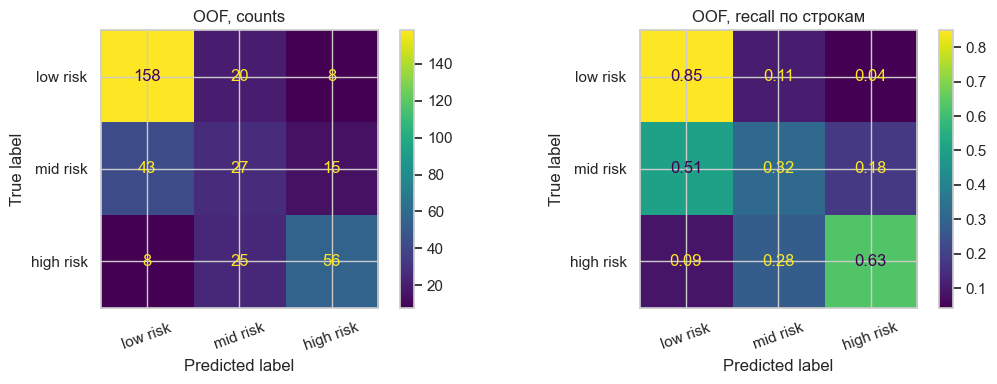

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
ConfusionMatrixDisplay.from_predictions(
    y_train, oof, labels=LABELS, ax=axes[0], xticks_rotation=20
)
axes[0].set_title("OOF, counts")

ConfusionMatrixDisplay.from_predictions(
    y_train, oof, labels=LABELS, normalize="true",
    values_format=".2f", ax=axes[1], xticks_rotation=20
)
axes[1].set_title("OOF, recall по строкам")
plt.tight_layout()
plt.show()

## Precision / recall / F1 по классам (OOF)

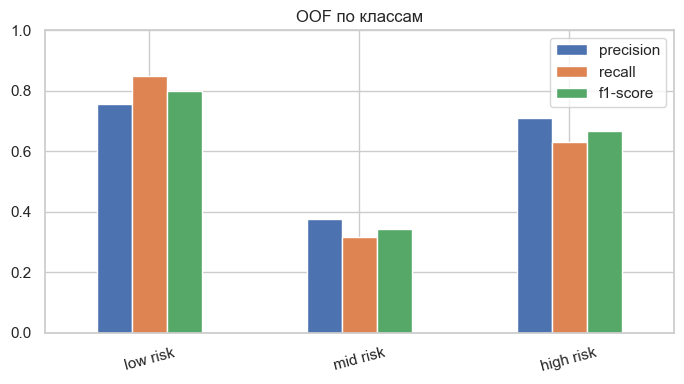

,precision,recall,f1-score
low risk,0.756,0.849,0.800
mid risk,0.375,0.318,0.344
high risk,0.709,0.629,0.667


In [29]:
rep = classification_report(y_train, oof, labels=LABELS, output_dict=True)
per = pd.DataFrame(rep).T.loc[LABELS, ["precision", "recall", "f1-score"]]
per.plot(kind="bar", ylim=(0, 1), figsize=(7, 4))
plt.xticks(rotation=15)
plt.title("OOF по классам")
plt.tight_layout()
plt.show()
display(per.round(3))